January vs December Comparison:
Revenue Growth: 1273.05%
Cost-Benefit Ratio: 1.25

June vs July Comparison:
Revenue Growth: 123.91%
Cost-Benefit Ratio: 1.25

January vs December Comparison:


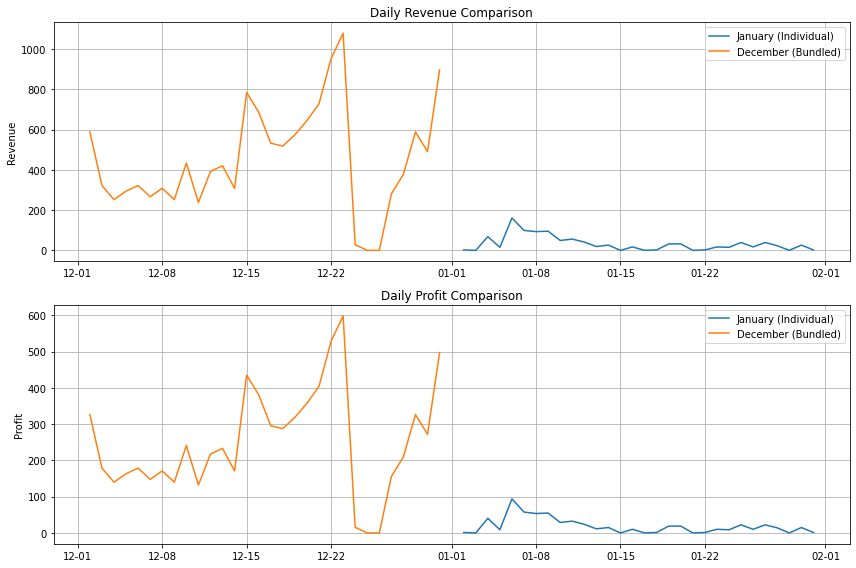


June vs July Comparison:


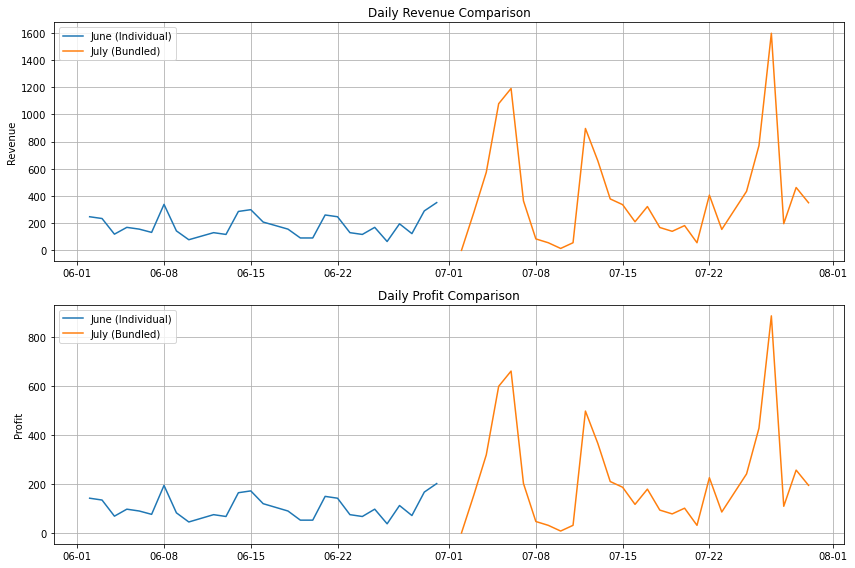

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

# Load data from Excel
def load_data():
    # Read individual sales data
    individual = pd.read_excel(r"C:\Users\mlule\Desktop\BEFORE AND AFTER BUNDLING (NOTHANDO).xlsx", 
                             sheet_name='INDIVIDUAL SALES', header=1)
    
    # Read bundled sales data
    bundled = pd.read_excel(r"C:\Users\mlule\Desktop\BEFORE AND AFTER BUNDLING (NOTHANDO).xlsx", 
                           sheet_name='BUNDLED 2LTR FIZZI+8PCR', header=1)
    
    return individual, bundled

# Process individual sales data
def process_individual(df, cols, month):
    df = df.iloc[:31, cols].copy()
    df.columns = ['date', 'fizzi_qty', 'fizzi_price', 'fizzi_cost', 
                 'pcr8_qty', 'pcr8_price', 'pcr8_cost']
    
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])
    
    # Convert to numeric types
    numeric_cols = ['fizzi_qty', 'fizzi_price', 'fizzi_cost', 
                   'pcr8_qty', 'pcr8_price', 'pcr8_cost']
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    
    # Calculate metrics
    df['total_revenue'] = (df['fizzi_qty'] * df['fizzi_price']) + (df['pcr8_qty'] * df['pcr8_price'])
    df['total_cost'] = (df['fizzi_qty'] * df['fizzi_cost']) + (df['pcr8_qty'] * df['pcr8_cost'])
    df['total_profit'] = df['total_revenue'] - df['total_cost']
    df['margin_pct'] = (df['total_profit'] / df['total_revenue']) * 100
    
    return df

# Process bundled sales data
def process_bundled(df, cols, month):
    df = df.iloc[:31, cols].copy()
    df.columns = ['date', 'bundle_qty', 'bundle_price', 'bundle_cost']
    
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])
    
    # Convert to numeric types
    numeric_cols = ['bundle_qty', 'bundle_price', 'bundle_cost']
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    
    # Calculate metrics
    df['total_revenue'] = df['bundle_qty'] * df['bundle_price']
    df['total_cost'] = df['bundle_qty'] * df['bundle_cost']
    df['total_profit'] = df['total_revenue'] - df['total_cost']
    df['margin_pct'] = (df['total_profit'] / df['total_revenue']) * 100
    
    return df

# Calculate comparative metrics
def calculate_comparative_metrics(individual_df, bundled_df):
    metrics = {}
    
    # Revenue Growth Rate
    metrics['revenue_growth_pct'] = (
        (bundled_df['total_revenue'].sum() - individual_df['total_revenue'].sum()) /
        individual_df['total_revenue'].sum()
    ) * 100
    
    # Cost-Benefit Ratio
    metrics['cost_benefit_ratio'] = (
        bundled_df['total_profit'].sum() / 
        bundled_df['total_cost'].sum()
    )
    
    return metrics

# Main analysis
individual, bundled = load_data()

# Process individual sales
jan = process_individual(individual, range(0,7), 'Jan')
jun = process_individual(individual, range(8,15), 'Jun')

# Process bundled sales
dec = process_bundled(bundled, range(0,4), 'Dec')
jul = process_bundled(bundled, range(5,9), 'Jul')

# Calculate comparative metrics
jan_dec_metrics = calculate_comparative_metrics(jan, dec)
jun_jul_metrics = calculate_comparative_metrics(jun, jul)

# Print results
print("January vs December Comparison:")
print(f"Revenue Growth: {jan_dec_metrics['revenue_growth_pct']:.2f}%")
print(f"Cost-Benefit Ratio: {jan_dec_metrics['cost_benefit_ratio']:.2f}\n")

print("June vs July Comparison:")
print(f"Revenue Growth: {jun_jul_metrics['revenue_growth_pct']:.2f}%")
print(f"Cost-Benefit Ratio: {jun_jul_metrics['cost_benefit_ratio']:.2f}")

# Visualization functions
def plot_comparison(before_df, after_df, before_label, after_label):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Revenue plot
    ax1.plot(before_df['date'], before_df['total_revenue'], label=before_label)
    ax1.plot(after_df['date'], after_df['total_revenue'], label=after_label)
    ax1.set_title('Daily Revenue Comparison')
    ax1.set_ylabel('Revenue')
    ax1.legend()
    ax1.grid(True)
    ax1.xaxis.set_major_formatter(DateFormatter("%m-%d"))
    
    # Profit plot
    ax2.plot(before_df['date'], before_df['total_profit'], label=before_label)
    ax2.plot(after_df['date'], after_df['total_profit'], label=after_label)
    ax2.set_title('Daily Profit Comparison')
    ax2.set_ylabel('Profit')
    ax2.legend()
    ax2.grid(True)
    ax2.xaxis.set_major_formatter(DateFormatter("%m-%d"))
    
    plt.tight_layout()
    plt.show()

# Generate comparison plots
print("\nJanuary vs December Comparison:")
plot_comparison(jan, dec, 'January (Individual)', 'December (Bundled)')

print("\nJune vs July Comparison:")
plot_comparison(jun, jul, 'June (Individual)', 'July (Bundled)')